# Análise ENEM 2023

## Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Caminho do arquivo
arquivo = './data/2023/MICRODADOS_ENEM_2023.csv'

# Carregamento dos dados
df = pd.read_csv(
    arquivo,
    sep=';',
    encoding='latin-1',
    low_memory=False
)

print(f"Dimensões do dataset: {df.shape[0]:,} linhas e {df.shape[1]} colunas")

Dimensões do dataset: 3,933,955 linhas e 76 colunas


In [3]:
# Visualizar as primeiras linhas
display(df.head())

# Informações gerais
df.info()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,F,E,D,5,F,C,C,D,C,D,C,B,B,D,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,E,E,B,3,H,A,B,C,C,A,B,B,B,A,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4305108,Caxias do Sul,43,RS,1,1,1,1,1221.00,1193.00,1204.00,1211.00,502.00,498.90,475.60,363.20,DBEBDCECCBCEBBBBDBABDDBBAABCBACDBACECCBAADEBB,ABDEADAADCDABDCADAEABCDDCBAADCCBEBCEBEBDBEAED,ACEBDCABAACAEBAECEBBBAAECBBDEADCAECCCEDDABEED,CEAEACCCDABCDAACEDDBAAEBABDDEEBDAECABDBCBCADE,1,DBEABDABDCACDBECDDDBCAAABBACCCADEBECCCEDAEEED,ACEEABAADCDAADEABCDABCDCABCBDADEBAECABADBCDAE,DBABBAEBAAAACDACDEDAACADBADBCCEACCCEAAECBBEBCA...,BCCDEEABCBEDCEABBEBDABDDADDADECAADDCCBEBEABCC,1.00,140.00,200.00,100.00,120.00,140.00,700.00,H,E,C,F,5,C,A,B,D,B,A,B,A,B,A,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,1.00,0,2304400.00,Fortaleza,23.00,CE,2.00,1.00,1.00,2304400,Fortaleza,23,CE,1,1,1,1,1224.00,1192.00,1202.00,1214.00,459.00,508.50,507.20,466.70,DEEBEACCCEBDDBDCCCAEEDCBAAADBCBEEEDCDAAECBEEC,DDAAEEBCCDEADBCDDCBAECABEBDEBDABECECEDCDDAEED,ADBDADAEEEACAABBACADCAEBBAAEBBCDEBBDDADDCADAA,EECBAEDEEDDDBBAADEECDBBBECEAACEAEECDBEDDBCDCB,0,CDDDABBABDBEABDECCEEEDCEDAEBABDCCAACCCADACDBE,DBAADEADCDCABABCDDEBAEABAECABAACECDAECBDAABCD,BBBDAABAEACCEEEDEACBCACAACAACAAAECBBEDBCCADBDE...,EBDADDAEBEACBEDCECCBEABCADEBCCBCCDEBDDAABBADD,1.00,140.00,200.00,160.00,180.00,200.00,880.00,D,D,B,B,5,C,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,1.00,0,2311306.00,Quixadá,23.00,CE,2.00,1.00,1.00,2311306,Quixadá,23,CE,1,1,1,1,1222.00,1191.00,1201.00,1212.00,402.50,379.20,446.90,338.30,AECCEAACDEABEEECDBAEEAAADDEABCBCEBACEEDCBEABD,CADEBCEDDEBCBAEBADDCECACADBDEBABDBDBEEDBBEADC,AABBACBCAEDABDADEDAACCAEEEECAACDCADBAEACDEAAE,CDBABEDCEEBBBDECDEBACCAABDEDCBECDECABBDBDEECC,0,CAAADCCCCDDDABDCACDBEEEDCEDAEECCDBEABDBABBAEB,CDAEECABAACEAADECBDAABCDCABADCDEABAABCDDEBADB,BBDABAAEBADACEEDCCDBADBDEDCCEBCACEACAACAACACBB...,DCECACCBDECBEEABEABDDAADDABBBCCBCCDDAEBDADEEB,1.00,120.00,120.00,120.00,120.00,80.00,560.00,B,B,A,A,4,B,A,B,A,A,A,B,A,A,A,A,A,A,B,A,A,B,A,A,A


<class 'pandas.DataFrame'>
RangeIndex: 3933955 entries, 0 to 3933954
Data columns (total 76 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   NU_INSCRICAO            int64  
 1   NU_ANO                  int64  
 2   TP_FAIXA_ETARIA         int64  
 3   TP_SEXO                 str    
 4   TP_ESTADO_CIVIL         int64  
 5   TP_COR_RACA             int64  
 6   TP_NACIONALIDADE        int64  
 7   TP_ST_CONCLUSAO         int64  
 8   TP_ANO_CONCLUIU         int64  
 9   TP_ESCOLA               int64  
 10  TP_ENSINO               float64
 11  IN_TREINEIRO            int64  
 12  CO_MUNICIPIO_ESC        float64
 13  NO_MUNICIPIO_ESC        str    
 14  CO_UF_ESC               float64
 15  SG_UF_ESC               str    
 16  TP_DEPENDENCIA_ADM_ESC  float64
 17  TP_LOCALIZACAO_ESC      float64
 18  TP_SIT_FUNC_ESC         float64
 19  CO_MUNICIPIO_PROVA      int64  
 20  NO_MUNICIPIO_PROVA      str    
 21  CO_UF_PROVA             int64  
 22  SG_UF

In [4]:
# Quantidade de valores ausentes por coluna
ausentes = df.isnull().sum()

# Exibir apenas colunas com valores ausentes
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)

display(ausentes)

CO_MUNICIPIO_ESC          2975449
NO_MUNICIPIO_ESC          2975449
CO_UF_ESC                 2975449
TP_DEPENDENCIA_ADM_ESC    2975449
SG_UF_ESC                 2975449
TP_LOCALIZACAO_ESC        2975449
TP_SIT_FUNC_ESC           2975449
TP_ENSINO                 2594874
CO_PROVA_CN               1241528
NU_NOTA_CN                1241528
CO_PROVA_MT               1241528
TX_RESPOSTAS_MT           1241528
TX_GABARITO_CN            1241528
TX_RESPOSTAS_CN           1241528
NU_NOTA_MT                1241528
TX_GABARITO_MT            1241528
NU_NOTA_CH                1111312
CO_PROVA_CH               1111312
CO_PROVA_LC               1111312
NU_NOTA_LC                1111312
TX_RESPOSTAS_LC           1111312
TX_GABARITO_CH            1111312
TX_RESPOSTAS_CH           1111312
TX_GABARITO_LC            1111312
TP_STATUS_REDACAO         1111312
NU_NOTA_COMP1             1111312
NU_NOTA_COMP2             1111312
NU_NOTA_COMP3             1111312
NU_NOTA_COMP4             1111312
NU_NOTA_COMP5 

In [5]:
df.shape

(3933955, 76)

## 3. Verificação de consistência dos dados.

In [6]:
# Variáveis de interesse inicial
variaveis = [
    'NU_INSCRICAO',
    'TP_FAIXA_ETARIA',
    'TP_SEXO',
    'TP_COR_RACA',
    'NO_MUNICIPIO_PROVA',
    'SG_UF_PROVA',
    'Q005',
    'Q006',
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO'
]

# Verificar inscrições duplicadas
duplicados = df['NU_INSCRICAO'].duplicated().sum()

print(f'Inscrições duplicadas: {duplicados:,}')

# Verificar valores ausentes
display(
    df[variaveis]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('VALORES_AUSENTES')
)

Inscrições duplicadas: 0


,VALORES_AUSENTES
NU_NOTA_CN,1241528
NU_NOTA_MT,1241528
NU_NOTA_CH,1111312
NU_NOTA_LC,1111312
NU_NOTA_REDACAO,1111312
NO_MUNICIPIO_PROVA,0
TP_COR_RACA,0
TP_SEXO,0
TP_FAIXA_ETARIA,0
NU_INSCRICAO,0


In [7]:
# Categorias e frequências
for coluna in [
    'TP_FAIXA_ETARIA',
    'TP_SEXO',
    'TP_COR_RACA',
    'Q005',
    'Q006'
]:
    print(f'\nDistribuição de {coluna}')
    display(
        df[coluna]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame('FREQUENCIA')
    )


Distribuição de TP_FAIXA_ETARIA


,FREQUENCIA
TP_FAIXA_ETARIA,
1,347434
2,753800
3,905047
4,431592
5,267383
6,183401
7,137884
8,111813
9,91359



Distribuição de TP_SEXO


,FREQUENCIA
TP_SEXO,
F,2411185
M,1522770



Distribuição de TP_COR_RACA


,FREQUENCIA
TP_COR_RACA,
0,52575
1,1575848
2,509511
3,1706798
4,64512
5,24711



Distribuição de Q005


,FREQUENCIA
Q005,
1,146875
2,567635
3,1086674
4,1247259
5,566325
6,194132
7,71049
8,29968
9,11192



Distribuição de Q006


,FREQUENCIA
Q006,
A,268053
B,1245271
C,650942
D,437366
E,293994
F,171344
G,261327
H,139279
I,85970


In [8]:
# Participantes por município de prova
df['NO_MUNICIPIO_PROVA'].value_counts().head(10)

NO_MUNICIPIO_PROVA
São Paulo         157220
Rio de Janeiro    116997
Fortaleza          74112
Brasília           72975
Salvador           69514
Belém              63314
Manaus             62200
Belo Horizonte     57959
São Luís           49133
Recife             47361
Name: count, dtype: int64

In [9]:
df[(df['NO_MUNICIPIO_PROVA'] == 'Santo Amaro') & (df['SG_UF_PROVA'] == 'BA')].shape

(1650, 76)

In [10]:
def tabela_frequencia(df, coluna):
    frequencia = df[coluna].value_counts(
        dropna=False
    ).sort_index()

    percentual = df[coluna].value_counts(
        normalize=True,
        dropna=False
    ).sort_index() * 100

    tabela = pd.DataFrame({
        'FREQUENCIA': frequencia,
        'PERCENTUAL': percentual
    })

    return tabela

In [11]:
# Filtrar participantes de Santo Amaro-BA
df_santo_amaro = df.loc[
    (df['NO_MUNICIPIO_PROVA'] == 'Santo Amaro') &
    (df['SG_UF_PROVA'] == 'BA')
]

print(f'Total de participantes: {len(df_santo_amaro):,}')

Total de participantes: 1,650


In [12]:
variaveis_perfil = [
    'Q006',
    'TP_COR_RACA',
    'TP_SEXO',
    'TP_FAIXA_ETARIA'
]

for coluna in variaveis_perfil:
    print(f'\nDistribuição de {coluna}')
    display(tabela_frequencia(df_santo_amaro, coluna))


Distribuição de Q006


,FREQUENCIA,PERCENTUAL
Q006,,
A,251,15.21
B,834,50.55
C,245,14.85
D,142,8.61
E,55,3.33
F,32,1.94
G,44,2.67
H,16,0.97
I,10,0.61



Distribuição de TP_COR_RACA


,FREQUENCIA,PERCENTUAL
TP_COR_RACA,,
0,18,1.09
1,90,5.45
2,930,56.36
3,592,35.88
4,13,0.79
5,7,0.42



Distribuição de TP_SEXO


,FREQUENCIA,PERCENTUAL
TP_SEXO,,
F,1092,66.18
M,558,33.82



Distribuição de TP_FAIXA_ETARIA


,FREQUENCIA,PERCENTUAL
TP_FAIXA_ETARIA,,
1,68,4.12
2,169,10.24
3,232,14.06
4,181,10.97
5,174,10.55
6,104,6.30
7,93,5.64
8,94,5.70
9,63,3.82


In [13]:
# Agrupamento das categorias oficiais de renda
grupos_renda = {
    'Sem renda': ['A'],
    'Até 1,5 SM': ['B', 'C'],
    'De 1,5 a 3 SM': ['D', 'E', 'F'],
    'De 3 a 6 SM': ['G', 'H', 'I'],
    'De 6 a 10 SM': ['J', 'K', 'L', 'M'],
    'Acima de 10 SM': ['N', 'O', 'P', 'Q']
}

# Mapeamento das categorias
mapa_renda = {
    categoria: grupo
    for grupo, categorias in grupos_renda.items()
    for categoria in categorias
}

# Criar a variável derivada em Santo Amaro
df_santo_amaro['GRUPO_RENDA'] = (
    df_santo_amaro['Q006'].map(mapa_renda)
)

# Distribuição absoluta
distribuicao_renda = (
    df_santo_amaro['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys(), fill_value=0)
)

# Distribuição percentual
percentuais_renda = (
    distribuicao_renda / distribuicao_renda.sum() * 100
).round(2)

# Tabela consolidada
tabela_renda = pd.DataFrame({
    'FREQUENCIA': distribuicao_renda,
    'PERCENTUAL': percentuais_renda
})

display(tabela_renda)

,FREQUENCIA,PERCENTUAL
GRUPO_RENDA,,
Sem renda,251,15.21
"Até 1,5 SM",1079,65.39
"De 1,5 a 3 SM",229,13.88
De 3 a 6 SM,70,4.24
De 6 a 10 SM,15,0.91
Acima de 10 SM,6,0.36


In [14]:
grupos_renda = {
    'Sem renda': ['A'],
    'Até 1,5 SM': ['B', 'C'],
    'De 1,5 a 3 SM': ['D', 'E', 'F'],
    'De 3 a 6 SM': ['G', 'H', 'I'],
    'De 6 a 10 SM': ['J', 'K', 'L', 'M'],
    'Acima de 10 SM': ['N', 'O', 'P', 'Q']
}

mapa_renda = {
    categoria: grupo
    for grupo, categorias in grupos_renda.items()
    for categoria in categorias
}

df_santo_amaro['GRUPO_RENDA'] = df_santo_amaro['Q006'].map(mapa_renda)

ordem_renda = list(grupos_renda.keys())

tabela_renda = (
    df_santo_amaro['GRUPO_RENDA']
    .value_counts()
    .reindex(ordem_renda, fill_value=0)
    .to_frame('FREQUENCIA')
)

tabela_renda['PERCENTUAL'] = (
    tabela_renda['FREQUENCIA'] / tabela_renda['FREQUENCIA'].sum() * 100
).round(2)

display(tabela_renda)

,FREQUENCIA,PERCENTUAL
GRUPO_RENDA,,
Sem renda,251,15.21
"Até 1,5 SM",1079,65.39
"De 1,5 a 3 SM",229,13.88
De 3 a 6 SM,70,4.24
De 6 a 10 SM,15,0.91
Acima de 10 SM,6,0.36


In [15]:
mapa_raca = {
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
}

ordem_raca = [
    'Não declarado',
    'Branca',
    'Preta',
    'Parda',
    'Amarela',
    'Indígena'
]

df_santo_amaro['RACA_COR'] = df_santo_amaro['TP_COR_RACA'].map(mapa_raca)

tabela_raca = (
    df_santo_amaro['RACA_COR']
    .value_counts()
    .reindex(ordem_raca, fill_value=0)
    .to_frame('FREQUENCIA')
)

tabela_raca['PERCENTUAL'] = (
    tabela_raca['FREQUENCIA'] / tabela_raca['FREQUENCIA'].sum() * 100
).round(2)

display(tabela_raca)

,FREQUENCIA,PERCENTUAL
RACA_COR,,
Não declarado,18,1.09
Branca,90,5.45
Preta,930,56.36
Parda,592,35.88
Amarela,13,0.79
Indígena,7,0.42


In [16]:
mapa_sexo = {
    'F': 'Feminino',
    'M': 'Masculino'
}

ordem_sexo = ['Feminino', 'Masculino']

df_santo_amaro['SEXO'] = df_santo_amaro['TP_SEXO'].map(mapa_sexo)

tabela_sexo = (
    df_santo_amaro['SEXO']
    .value_counts()
    .reindex(ordem_sexo, fill_value=0)
    .to_frame('FREQUENCIA')
)

tabela_sexo['PERCENTUAL'] = (
    tabela_sexo['FREQUENCIA'] / tabela_sexo['FREQUENCIA'].sum() * 100
).round(2)

display(tabela_sexo)

,FREQUENCIA,PERCENTUAL
SEXO,,
Feminino,1092,66.18
Masculino,558,33.82


In [17]:
mapa_idade = {
    1: 'Menor de 17 anos',
    2: '17 anos',
    3: '18 anos',
    4: '19 anos',
    5: '20 anos',
    6: '21 anos',
    7: '22 anos',
    8: '23 anos',
    9: '24 anos',
    10: '25 anos',
    11: '26 a 30 anos',
    12: '31 a 35 anos',
    13: '36 a 40 anos',
    14: '41 a 45 anos',
    15: '46 a 50 anos',
    16: '51 a 55 anos',
    17: '56 a 60 anos',
    18: '61 a 65 anos',
    19: '66 a 70 anos',
    20: 'Maior de 70 anos'
}

ordem_idade = list(mapa_idade.values())

df_santo_amaro['FAIXA_ETARIA'] = (
    df_santo_amaro['TP_FAIXA_ETARIA'].map(mapa_idade)
)

tabela_idade = (
    df_santo_amaro['FAIXA_ETARIA']
    .value_counts()
    .reindex(ordem_idade, fill_value=0)
    .to_frame('FREQUENCIA')
)

tabela_idade['PERCENTUAL'] = (
    tabela_idade['FREQUENCIA'] / tabela_idade['FREQUENCIA'].sum() * 100
).round(2)

display(tabela_idade)

,FREQUENCIA,PERCENTUAL
FAIXA_ETARIA,,
Menor de 17 anos,68,4.12
17 anos,169,10.24
18 anos,232,14.06
19 anos,181,10.97
20 anos,174,10.55
21 anos,104,6.30
22 anos,93,5.64
23 anos,94,5.70
24 anos,63,3.82


In [18]:
colunas_notas = [
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO'
]

nomes_areas = {
    'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_CH': 'Ciências Humanas',
    'NU_NOTA_LC': 'Linguagens',
    'NU_NOTA_MT': 'Matemática',
    'NU_NOTA_REDACAO': 'Redação'
}

estatisticas_notas = (
    df_santo_amaro[colunas_notas]
    .describe()
    .T
    .rename(index=nomes_areas)
    .rename(columns={
        'count': 'N',
        'mean': 'Média',
        'std': 'Desvio-padrão',
        'min': 'Mínimo',
        '25%': 'Q1',
        '50%': 'Mediana',
        '75%': 'Q3',
        'max': 'Máximo'
    })
)

estatisticas_notas = estatisticas_notas.round(2)

display(estatisticas_notas)

,N,Média,Desvio-padrão,Mínimo,Q1,Mediana,Q3,Máximo
Ciências da Natureza,1098.00,466.15,66.53,326.60,418.60,462.15,511.55,692.50
Ciências Humanas,1141.00,490.60,86.28,0.00,429.50,491.30,551.70,732.00
Linguagens,1141.00,490.20,74.00,287.70,439.60,491.90,541.30,754.30
Matemática,1098.00,465.51,101.62,328.70,384.52,440.55,523.28,831.70
Redação,1141.00,532.29,190.92,0.00,420.00,540.00,640.00,980.00


In [19]:
analise_zeros = pd.DataFrame({
    'NOTAS_ZERO': (df_santo_amaro[colunas_notas] == 0).sum(),
    'NOTAS_VALIDAS': df_santo_amaro[colunas_notas].count()
})

analise_zeros['PERCENTUAL_ZERO'] = (
    analise_zeros['NOTAS_ZERO'] /
    analise_zeros['NOTAS_VALIDAS'] * 100
).round(2)

analise_zeros.index = [
    nomes_areas[coluna] for coluna in analise_zeros.index
]

display(analise_zeros)

,NOTAS_ZERO,NOTAS_VALIDAS,PERCENTUAL_ZERO
Ciências da Natureza,0,1098,0.00
Ciências Humanas,2,1141,0.18
Linguagens,0,1141,0.00
Matemática,0,1098,0.00
Redação,46,1141,4.03


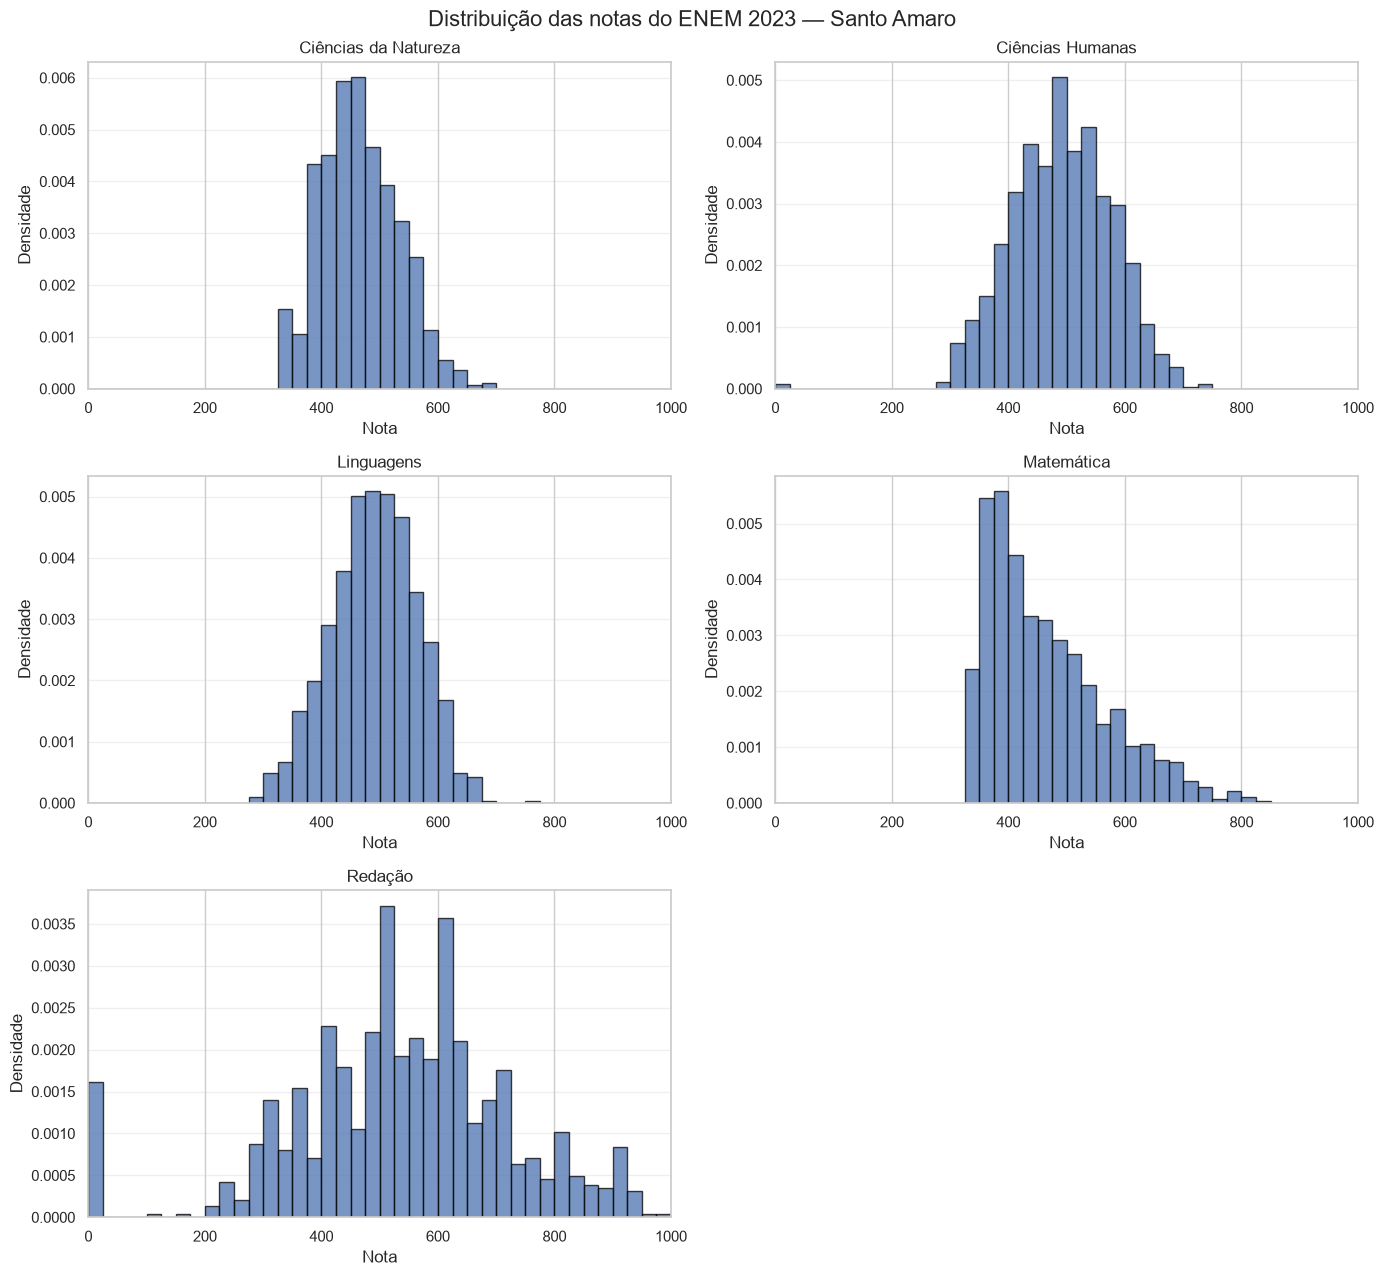

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

bins = np.arange(0, 1025, 25)

for i, coluna in enumerate(colunas_notas):
    notas = df_santo_amaro[coluna].dropna()

    axes[i].hist(
        notas,
        bins=bins,
        density=True,
        edgecolor='black',
        alpha=0.75
    )

    axes[i].set_title(nomes_areas[coluna])
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Densidade')
    axes[i].set_xlim(0, 1000)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].axis('off')

fig.suptitle(
    'Distribuição das notas do ENEM 2023 — Santo Amaro',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Análise Brasil

In [21]:
# Distribuição nacional de participantes por UF
distribuicao_uf = (
    df['SG_UF_PROVA']
    .value_counts()
    .sort_index()
    .to_frame('PARTICIPANTES')
)

distribuicao_uf['PERCENTUAL'] = (
    distribuicao_uf['PARTICIPANTES'] /
    distribuicao_uf['PARTICIPANTES'].sum() * 100
).round(2)

display(distribuicao_uf)

print(f"Total de participantes: {len(df):,}".replace(',', '.'))
print(f"Quantidade de UFs: {df['SG_UF_PROVA'].nunique()}")

,PARTICIPANTES,PERCENTUAL
SG_UF_PROVA,,
AC,24274,0.62
AL,82760,2.10
AM,92916,2.36
AP,28807,0.73
BA,324268,8.24
CE,241960,6.15
DF,72975,1.86
ES,73724,1.87
GO,149110,3.79


Total de participantes: 3.933.955
Quantidade de UFs: 27


In [22]:
disponibilidade_notas = pd.DataFrame({
    'NOTAS_VALIDAS': df[colunas_notas].count(),
    'NOTAS_AUSENTES': df[colunas_notas].isna().sum()
})

disponibilidade_notas.index = [
    nomes_areas[coluna] for coluna in disponibilidade_notas.index
]

display(disponibilidade_notas)

,NOTAS_VALIDAS,NOTAS_AUSENTES
Ciências da Natureza,2692427,1241528
Ciências Humanas,2822643,1111312
Linguagens,2822643,1111312
Matemática,2692427,1241528
Redação,2822643,1111312


## Amostra Nacional

In [23]:
N_AMOSTRA = 100_000
SEED = 42

proporcao_uf = (
    df['SG_UF_PROVA']
    .value_counts(normalize=True)
)

n_por_uf = (
    proporcao_uf * N_AMOSTRA
).round().astype(int)

amostras = []

for uf, n in n_por_uf.items():
    df_uf = df[df['SG_UF_PROVA'] == uf]

    amostra_uf = df_uf.sample(
        n=n,
        random_state=SEED
    )

    amostras.append(amostra_uf)

df_nacional = pd.concat(
    amostras,
    ignore_index=True
)

print(f'Tamanho da amostra: {len(df_nacional):,}'.replace(',', '.'))

Tamanho da amostra: 100.000


In [24]:
comparacao_uf = pd.DataFrame({
    'POPULACAO': df['SG_UF_PROVA'].value_counts(),
    'AMOSTRA': df_nacional['SG_UF_PROVA'].value_counts()
})

comparacao_uf['% POPULACAO'] = (
    comparacao_uf['POPULACAO'] /
    comparacao_uf['POPULACAO'].sum() * 100
)

comparacao_uf['% AMOSTRA'] = (
    comparacao_uf['AMOSTRA'] /
    comparacao_uf['AMOSTRA'].sum() * 100
)

comparacao_uf['DIFERENCA_pp'] = (
    comparacao_uf['% AMOSTRA'] -
    comparacao_uf['% POPULACAO']
)

comparacao_uf = comparacao_uf.sort_index().round(2)

display(comparacao_uf)

,POPULACAO,AMOSTRA,% POPULACAO,% AMOSTRA,DIFERENCA_pp
SG_UF_PROVA,,,,,
AC,24274,617,0.62,0.62,-0.00
AL,82760,2104,2.10,2.10,0.00
AM,92916,2362,2.36,2.36,0.00
AP,28807,732,0.73,0.73,-0.00
BA,324268,8243,8.24,8.24,0.00
CE,241960,6151,6.15,6.15,0.00
DF,72975,1855,1.86,1.86,-0.00
ES,73724,1874,1.87,1.87,-0.00
GO,149110,3790,3.79,3.79,-0.00


In [25]:
disponibilidade_nacional = pd.DataFrame({
    'NOTAS_VALIDAS': df_nacional[colunas_notas].count(),
    'NOTAS_AUSENTES': df_nacional[colunas_notas].isna().sum()
})

disponibilidade_nacional.index = [
    nomes_areas[coluna] for coluna in disponibilidade_nacional.index
]

disponibilidade_nacional['PERCENTUAL_VALIDAS'] = (
    disponibilidade_nacional['NOTAS_VALIDAS'] /
    len(df_nacional) * 100
).round(2)

display(disponibilidade_nacional)

,NOTAS_VALIDAS,NOTAS_AUSENTES,PERCENTUAL_VALIDAS
Ciências da Natureza,68422,31578,68.42
Ciências Humanas,71723,28277,71.72
Linguagens,71723,28277,71.72
Matemática,68422,31578,68.42
Redação,71723,28277,71.72


In [26]:
comparacao_notas = pd.DataFrame({
    'POPULACAO_VALIDAS': df[colunas_notas].count(),
    'AMOSTRA_VALIDAS': df_nacional[colunas_notas].count()
})

comparacao_notas.index = [
    nomes_areas[coluna] for coluna in comparacao_notas.index
]

comparacao_notas['% POPULACAO'] = (
    comparacao_notas['POPULACAO_VALIDAS'] /
    len(df) * 100
).round(2)

comparacao_notas['% AMOSTRA'] = (
    comparacao_notas['AMOSTRA_VALIDAS'] /
    len(df_nacional) * 100
).round(2)

comparacao_notas['DIFERENCA_pp'] = (
    comparacao_notas['% AMOSTRA'] -
    comparacao_notas['% POPULACAO']
).round(2)

display(comparacao_notas)

,POPULACAO_VALIDAS,AMOSTRA_VALIDAS,% POPULACAO,% AMOSTRA,DIFERENCA_pp
Ciências da Natureza,2692427,68422,68.44,68.42,-0.02
Ciências Humanas,2822643,71723,71.75,71.72,-0.03
Linguagens,2822643,71723,71.75,71.72,-0.03
Matemática,2692427,68422,68.44,68.42,-0.02
Redação,2822643,71723,71.75,71.72,-0.03


## Comparação Santo Amaro X Brasil

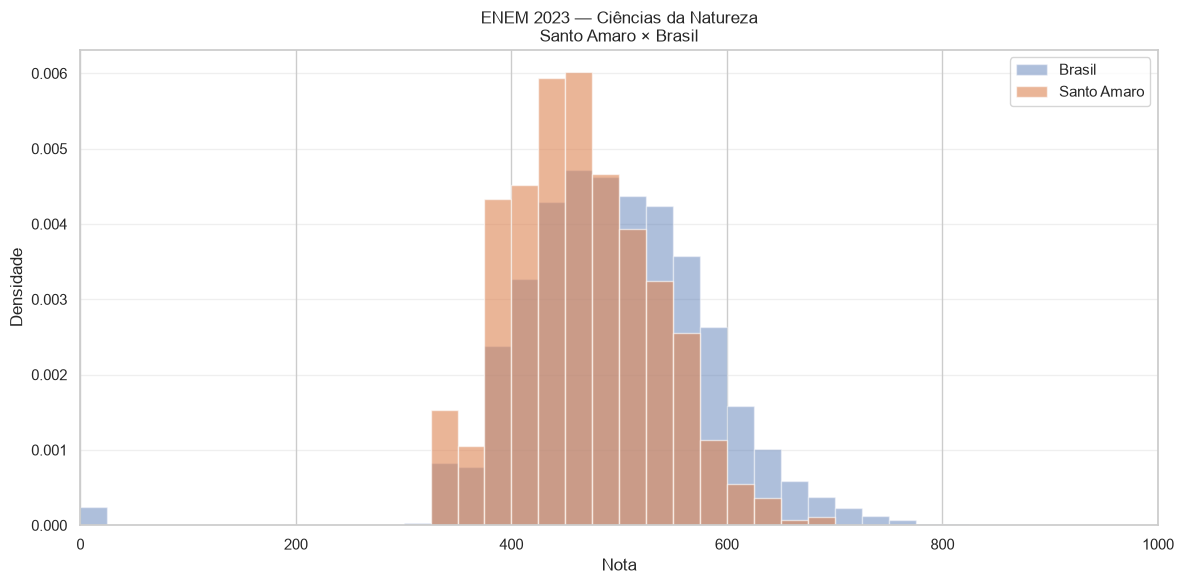

In [27]:
import matplotlib.pyplot as plt
import numpy as np

coluna = 'NU_NOTA_CN'

notas_santo = df_santo_amaro[coluna].dropna()
notas_nacional = df_nacional[coluna].dropna()

bins = np.arange(0, 1025, 25)

plt.figure(figsize=(12, 6))

plt.hist(
    notas_nacional,
    bins=bins,
    density=True,
    alpha=0.45,
    label='Brasil'
)

plt.hist(
    notas_santo,
    bins=bins,
    density=True,
    alpha=0.60,
    label='Santo Amaro'
)

plt.title(
    'ENEM 2023 — Ciências da Natureza\n'
    'Santo Amaro × Brasil'
)

plt.xlabel('Nota')
plt.ylabel('Densidade')

plt.xlim(0, 1000)

plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

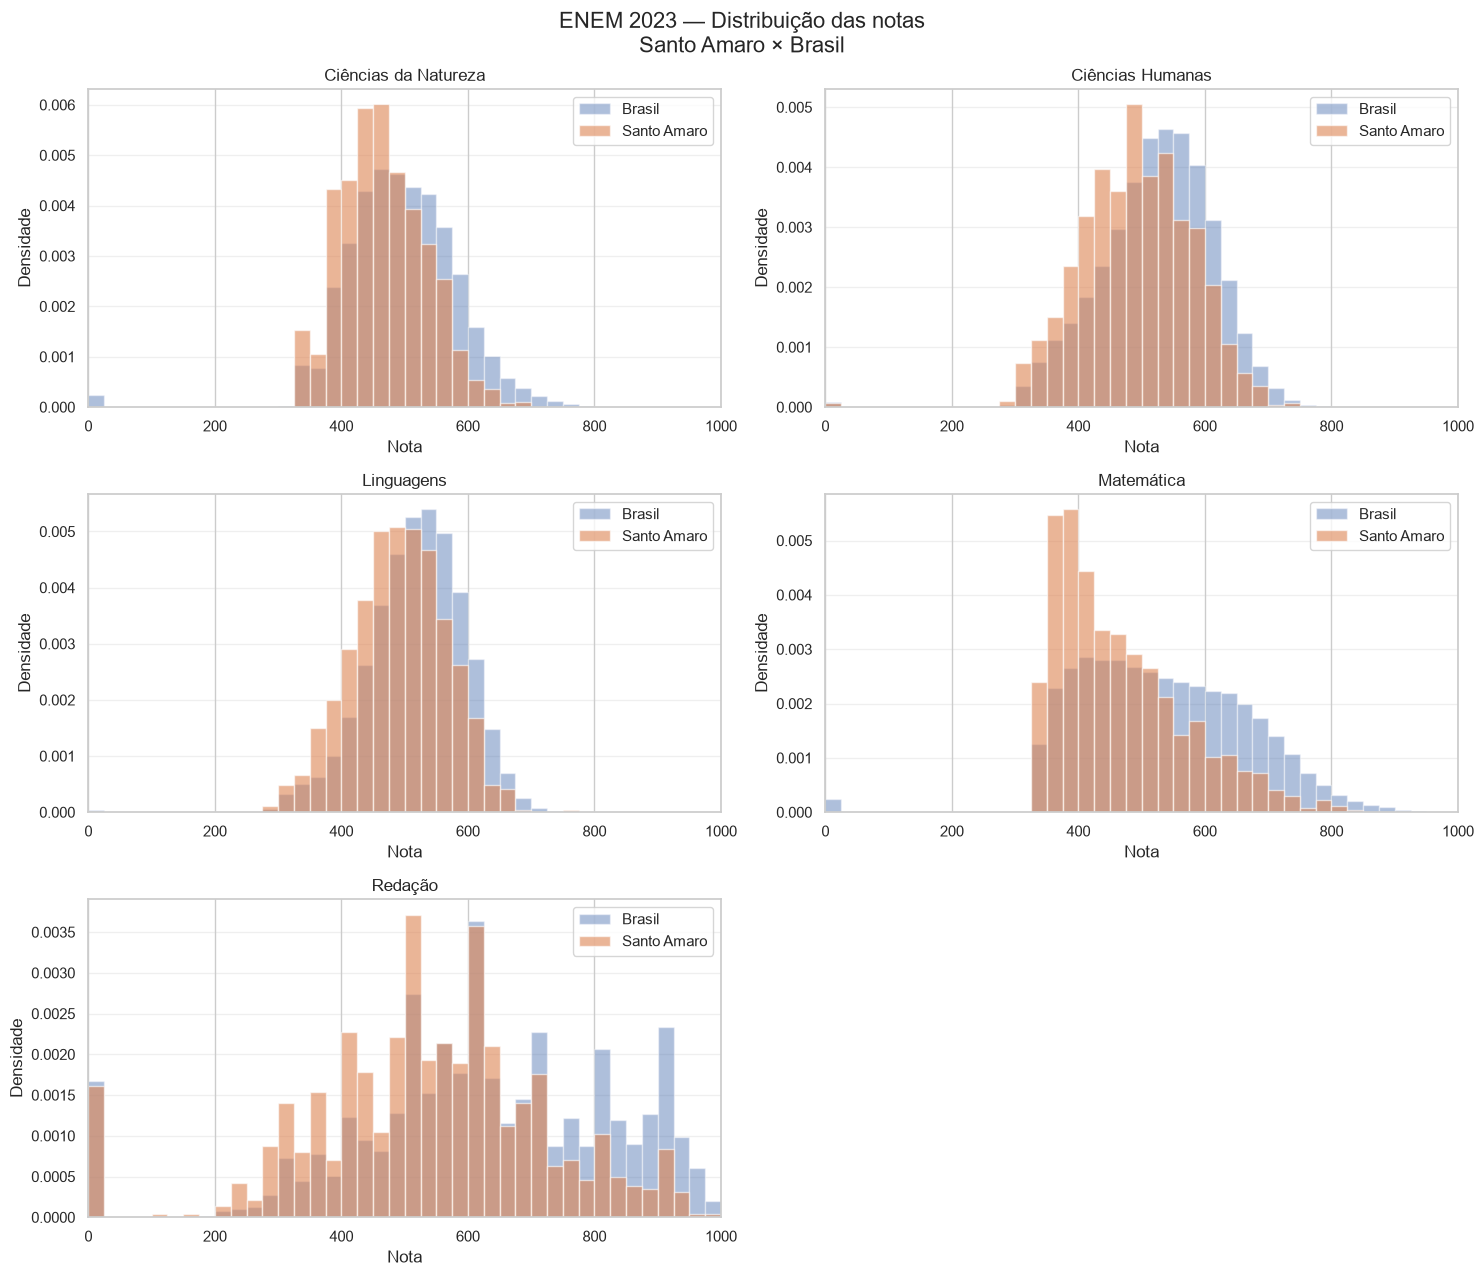

In [28]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(0, 1025, 25)

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.flatten()

for i, coluna in enumerate(colunas_notas):

    notas_santo = df_santo_amaro[coluna].dropna()
    notas_nacional = df_nacional[coluna].dropna()

    axes[i].hist(
        notas_nacional,
        bins=bins,
        density=True,
        alpha=0.45,
        label='Brasil'
    )

    axes[i].hist(
        notas_santo,
        bins=bins,
        density=True,
        alpha=0.60,
        label='Santo Amaro'
    )

    axes[i].set_title(nomes_areas[coluna])
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Densidade')
    axes[i].set_xlim(0, 1000)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].legend()

axes[-1].axis('off')

fig.suptitle(
    'ENEM 2023 — Distribuição das notas\nSanto Amaro × Brasil',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [29]:
estatisticas_comparativas = []

for coluna in colunas_notas:

    notas_santo = df_santo_amaro[coluna].dropna()
    notas_brasil = df_nacional[coluna].dropna()

    estatisticas_comparativas.append({
        'Área': nomes_areas[coluna],

        'N Santo Amaro': len(notas_santo),
        'N Brasil': len(notas_brasil),

        'Média Santo Amaro': notas_santo.mean(),
        'Média Brasil': notas_brasil.mean(),

        'Mediana Santo Amaro': notas_santo.median(),
        'Mediana Brasil': notas_brasil.median(),

        'Desvio-padrão Santo Amaro': notas_santo.std(),
        'Desvio-padrão Brasil': notas_brasil.std(),

        'Q1 Santo Amaro': notas_santo.quantile(0.25),
        'Q1 Brasil': notas_brasil.quantile(0.25),

        'Q3 Santo Amaro': notas_santo.quantile(0.75),
        'Q3 Brasil': notas_brasil.quantile(0.75),
    })

comparacao_notas = pd.DataFrame(estatisticas_comparativas)

comparacao_notas['Diferença média'] = (
    comparacao_notas['Média Santo Amaro'] -
    comparacao_notas['Média Brasil']
)

comparacao_notas = comparacao_notas.round(2)

display(comparacao_notas)

,Área,N Santo Amaro,N Brasil,Média Santo Amaro,Média Brasil,Mediana Santo Amaro,Mediana Brasil,Desvio-padrão Santo Amaro,Desvio-padrão Brasil,Q1 Santo Amaro,Q1 Brasil,Q3 Santo Amaro,Q3 Brasil,Diferença média
0,Ciências da Natureza,1098,68422,466.15,495.69,462.15,493.40,66.53,88.07,418.60,439.60,511.55,551.30,-29.54
1,Ciências Humanas,1141,71723,490.60,523.21,491.30,529.80,86.28,88.49,429.50,468.00,551.70,584.70,-32.61
2,Linguagens,1141,71723,490.20,518.32,491.90,522.80,74.00,75.34,439.60,471.65,541.30,570.55,-28.13
3,Matemática,1098,68422,465.51,533.74,440.55,523.70,101.62,131.57,384.52,431.20,523.28,629.90,-68.23
4,Redação,1141,71723,532.29,618.12,540.00,620.00,190.92,215.00,420.00,500.00,640.00,780.00,-85.83


## Comparação Renda X Desempenho

In [32]:
df_santo_amaro[['Q005', 'Q006']].head()


,Q005,Q006
413,4,D
2224,2,B
4260,1,B
5898,4,A
6988,3,B


In [33]:
df_santo_amaro[['Q005', 'Q006']].dtypes

Q005    int64
Q006      str
dtype: object

In [34]:
df_santo_amaro['Q006'].value_counts().sort_index()

Q006
A    251
B    834
C    245
D    142
E     55
F     32
G     44
H     16
I     10
J      3
K      4
L      3
M      5
N      4
P      1
Q      1
Name: count, dtype: int64

In [35]:
mapa_renda_2023 = {
    'A': 0,
    'B': 660,
    'C': 1650,
    'D': 2310,
    'E': 2970,
    'F': 3630,
    'G': 4620,
    'H': 5940,
    'I': 7260,
    'J': 8580,
    'K': 9900,
    'L': 11220,
    'M': 12540,
    'N': 14520,
    'O': 17820,
    'P': 23100,
    'Q': np.nan
}

df_santo_amaro['RENDA_FAMILIAR_EST'] = (
    df_santo_amaro['Q006'].map(mapa_renda_2023)
)

In [36]:
df_santo_amaro['RENDA_PER_CAP_EST'] = (
    df_santo_amaro['RENDA_FAMILIAR_EST'] /
    df_santo_amaro['Q005']
)

In [37]:
display(
    df_santo_amaro[
        ['Q005', 'Q006', 'RENDA_FAMILIAR_EST', 'RENDA_PER_CAP_EST']
    ].head(10)
)

,Q005,Q006,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST
413,4,D,2310.00,577.50
2224,2,B,660.00,330.00
4260,1,B,660.00,660.00
5898,4,A,0.00,0.00
6988,3,B,660.00,220.00
8391,2,B,660.00,330.00
10483,3,A,0.00,0.00
12370,3,B,660.00,220.00
14599,4,B,660.00,165.00
20234,1,C,1650.00,1650.00


In [38]:
LIMIAR_BAIXA_RENDA = 660.00

df_santo_amaro['BAIXA_RENDA_EST'] = (
    df_santo_amaro['RENDA_PER_CAP_EST']
    .le(LIMIAR_BAIXA_RENDA)
    .map({True: 'Sim', False: 'Não'})
)

In [39]:
df_santo_amaro['BAIXA_RENDA_EST'].value_counts()

BAIXA_RENDA_EST
Sim    1379
Não     271
Name: count, dtype: int64

In [40]:
df_santo_amaro['BAIXA_RENDA_EST'].value_counts(normalize=True).mul(100).round(2)

BAIXA_RENDA_EST
Sim   83.58
Não   16.42
Name: proportion, dtype: float64

In [41]:
colunas_notas = [
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO'
]

df_santo_amaro['N_NOTAS_VALIDAS'] = (
    df_santo_amaro[colunas_notas].notna().sum(axis=1)
)

df_santo_amaro['N_NOTAS_VALIDAS'].value_counts().sort_index()

N_NOTAS_VALIDAS
0     500
2       9
3      52
5    1089
Name: count, dtype: int64

In [42]:
df_santo_amaro['MEDIA_ENEM'] = (
    df_santo_amaro[colunas_notas].mean(axis=1)
)

In [43]:
dados = df_santo_amaro[
    df_santo_amaro['N_NOTAS_VALIDAS'] == 5
][
    ['RENDA_PER_CAP_EST', 'MEDIA_ENEM', 'BAIXA_RENDA_EST']
].dropna()

In [44]:
display(dados.describe())

,RENDA_PER_CAP_EST,MEDIA_ENEM
count,1088.00,1088.00
mean,442.31,490.73
std,588.93,81.19
min,0.00,268.30
25%,165.00,432.32
50%,220.00,488.06
75%,550.00,543.44
max,6270.00,763.96


In [45]:
df_santo_amaro['MEDIA_ENEM'] = (
    df_santo_amaro[colunas_notas].mean(axis=1)
)

In [46]:
dados = df_santo_amaro[
    df_santo_amaro['N_NOTAS_VALIDAS'] == 5
][
    ['RENDA_PER_CAP_EST', 'MEDIA_ENEM', 'BAIXA_RENDA_EST']
].dropna()

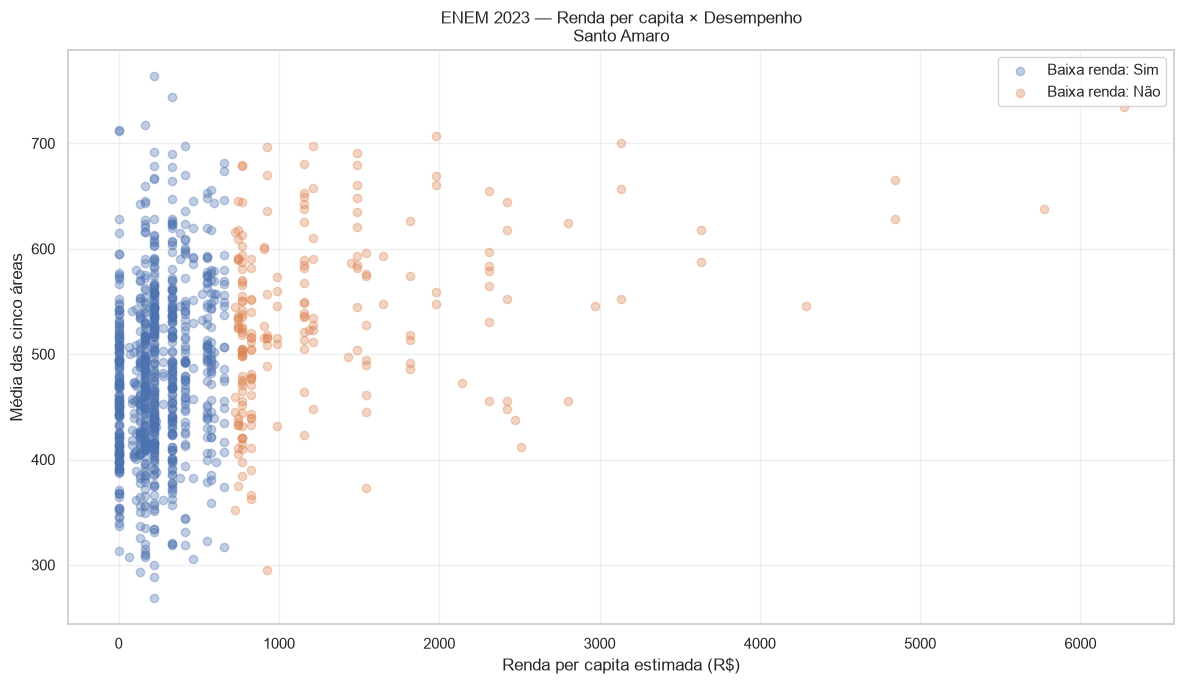

In [47]:
plt.figure(figsize=(12, 7))

for categoria in ['Sim', 'Não']:
    grupo = dados[dados['BAIXA_RENDA_EST'] == categoria]

    plt.scatter(
        grupo['RENDA_PER_CAP_EST'],
        grupo['MEDIA_ENEM'],
        alpha=0.35,
        label=f'Baixa renda: {categoria}'
    )

plt.title(
    'ENEM 2023 — Renda per capita × Desempenho\n'
    'Santo Amaro'
)
plt.xlabel('Renda per capita estimada (R$)')
plt.ylabel('Média das cinco áreas')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
SM_2023 = 1320.00

limites = [
    0,
    1.5 * SM_2023,
    3 * SM_2023,
    6 * SM_2023,
    10 * SM_2023
]

rotulos = [
    'Sem renda',
    'Até 1,5 SM',
    'De 1,5 a 3 SM',
    'De 3 a 6 SM',
    'De 6 a 10 SM',
    'Acima de 10 SM'
]

In [49]:
def classificar_renda_per_capita(renda):
    if pd.isna(renda):
        return np.nan
    elif renda == 0:
        return 'Sem renda'
    elif renda <= 1.5 * SM_2023:
        return 'Até 1,5 SM'
    elif renda <= 3 * SM_2023:
        return 'De 1,5 a 3 SM'
    elif renda <= 6 * SM_2023:
        return 'De 3 a 6 SM'
    elif renda <= 10 * SM_2023:
        return 'De 6 a 10 SM'
    else:
        return 'Acima de 10 SM'

df_santo_amaro['GRUPO_RENDA_PER_CAP'] = (
    df_santo_amaro['RENDA_PER_CAP_EST']
    .apply(classificar_renda_per_capita)
)

In [50]:
df_santo_amaro['GRUPO_RENDA_PER_CAP'].value_counts()

GRUPO_RENDA_PER_CAP
Até 1,5 SM       1367
Sem renda         251
De 1,5 a 3 SM      26
De 3 a 6 SM         5
Name: count, dtype: int64

In [51]:
ordem_grupos = [
    'Sem renda',
    'Até 1,5 SM',
    'De 1,5 a 3 SM',
    'De 3 a 6 SM',
    'De 6 a 10 SM',
    'Acima de 10 SM'
]

df_santo_amaro['GRUPO_RENDA_PER_CAP'] = pd.Categorical(
    df_santo_amaro['GRUPO_RENDA_PER_CAP'],
    categories=ordem_grupos,
    ordered=True
)

In [52]:
dados_renda = df_santo_amaro[
    (df_santo_amaro['N_NOTAS_VALIDAS'] == 5) &
    (df_santo_amaro['RENDA_PER_CAP_EST'].notna())
].copy()

In [53]:
media_por_grupo = (
    dados_renda
    .groupby('GRUPO_RENDA_PER_CAP', observed=False)['MEDIA_ENEM']
    .agg(['count', 'mean'])
    .reindex(ordem_grupos)
)

media_por_grupo

,count,mean
GRUPO_RENDA_PER_CAP,,
Sem renda,154,461.50
"Até 1,5 SM",906,493.26
"De 1,5 a 3 SM",23,554.08
De 3 a 6 SM,5,642.40
De 6 a 10 SM,0,NaN
Acima de 10 SM,0,NaN


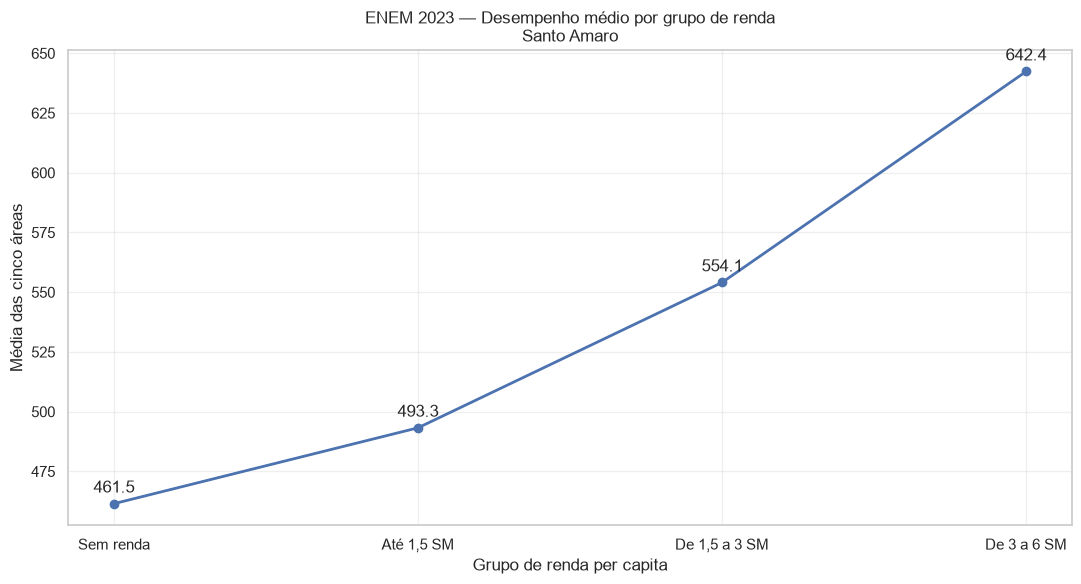

In [54]:
media_por_grupo_plot = (
    media_por_grupo
    .dropna(subset=['mean'])
    .reset_index()
)

plt.figure(figsize=(11, 6))

plt.plot(
    media_por_grupo_plot['GRUPO_RENDA_PER_CAP'],
    media_por_grupo_plot['mean'],
    marker='o',
    linewidth=2
)

for _, linha in media_por_grupo_plot.iterrows():
    plt.annotate(
        f"{linha['mean']:.1f}",
        (linha['GRUPO_RENDA_PER_CAP'], linha['mean']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )

plt.title(
    'ENEM 2023 — Desempenho médio por grupo de renda\n'
    'Santo Amaro'
)
plt.xlabel('Grupo de renda per capita')
plt.ylabel('Média das cinco áreas')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()